In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# USER SETUP:
# Upload "Tetuan City power consumption.csv" to MyDrive.
# If you use another Drive folder, change only DATA_PATH.

DATA_PATH = "/content/drive/MyDrive/Tetuan City power consumption.csv"

RESULT_PATH = "/content/drive/MyDrive/tetouan_power_model_results.csv"
PREDICTION_PATH = "/content/drive/MyDrive/tetouan_power_predictions.csv"
IMPORTANCE_PATH = "/content/drive/MyDrive/tetouan_power_feature_importance.csv"

R2_GRAPH_PATH = "/content/drive/MyDrive/tetouan_power_r2_comparison.png"
PRED_GRAPH_PATH = "/content/drive/MyDrive/tetouan_power_actual_vs_predicted.png"
IMPORTANCE_GRAPH_PATH = "/content/drive/MyDrive/tetouan_power_feature_importance.png"

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        'Upload "Tetuan City power consumption.csv" to Google Drive or update DATA_PATH.'
    )

In [4]:
# Load and inspect the data.
df = pd.read_csv(DATA_PATH)

print("Original dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
display(df.head())
print("\nMissing values:", int(df.isna().sum().sum()))

Original dataset shape: (52416, 9)

Columns:
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964



Missing values: 0


In [5]:
# Parse time and create cyclical time features.
df["DateTime"] = pd.to_datetime(df["DateTime"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["DateTime"]).sort_values("DateTime").reset_index(drop=True)

df["hour_sin"] = np.sin(2 * np.pi * df["DateTime"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["DateTime"].dt.hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["DateTime"].dt.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["DateTime"].dt.dayofweek / 7)
df["month_sin"] = np.sin(2 * np.pi * df["DateTime"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["DateTime"].dt.month / 12)

TARGET = "Zone 1 Power Consumption"

# Zone 2 and Zone 3 are excluded from predictors to avoid using simultaneous
# consumption in other zones as an easy proxy for the Zone 1 target.
excluded = [
    "DateTime",
    TARGET,
    "Zone 2  Power Consumption",
    "Zone 3  Power Consumption",
    "Zone 2 Power Consumption",
    "Zone 3 Power Consumption"
]

X = df.drop(columns=[c for c in excluded if c in df.columns])
y = df[TARGET].astype(float)

print("Target:", TARGET)
print("Model input shape:", X.shape)
display(X.head())
print("\nTarget summary:")
display(y.describe().to_frame().T)

Target: Zone 1 Power Consumption
Model input shape: (20736, 11)


,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,6.559,73.8,0.083,0.051,0.119,0.0,1.0,-0.781831,0.62349,0.5,0.866025
1,6.414,74.5,0.083,0.070,0.085,0.0,1.0,-0.781831,0.62349,0.5,0.866025
2,6.313,74.5,0.080,0.062,0.100,0.0,1.0,-0.781831,0.62349,0.5,0.866025
3,6.121,75.0,0.083,0.091,0.096,0.0,1.0,-0.781831,0.62349,0.5,0.866025
4,5.921,75.7,0.081,0.048,0.085,0.0,1.0,-0.781831,0.62349,0.5,0.866025



Target summary:


,count,mean,std,min,25%,50%,75%,max
Zone 1 Power Consumption,20736.0,32086.712491,7053.231363,17624.3346,26165.609202,31935.028565,36950.46358,52204.39512


In [6]:
# Chronological 80/20 split.
split_point = int(len(X) * 0.80)

X_train = X.iloc[:split_point].copy()
X_test = X.iloc[split_point:].copy()
y_train = y.iloc[:split_point].copy()
y_test = y.iloc[split_point:].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Train period:", df.loc[:split_point - 1, "DateTime"].min(), "to", df.loc[:split_point - 1, "DateTime"].max())
print("Test period:", df.loc[split_point:, "DateTime"].min(), "to", df.loc[split_point:, "DateTime"].max())

Training rows: 16588
Testing rows: 4148
Train period: 2017-01-01 00:00:00 to 2017-10-08 04:30:00
Test period: 2017-10-08 04:40:00 to 2017-12-12 23:50:00


In [7]:
# Build the two regression models.
# StandardScaler is applied to predictors, while TransformedTargetRegressor
# standardises the target internally and reverses the transformation for predictions.

linear_svr = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scale_x", StandardScaler()),
        ("model", LinearSVR(
            C=1.0,
            epsilon=0.1,
            loss="squared_epsilon_insensitive",
            random_state=42,
            max_iter=20000
        ))
    ]),
    transformer=StandardScaler()
)

neural_net = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scale_x", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=250,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=20,
            random_state=42
        ))
    ]),
    transformer=StandardScaler()
)

models = {
    "Linear SVR": linear_svr,
    "MLP Neural Network": neural_net
}

In [8]:
# Train and compare models using regression metrics.
results = []
prediction_table = pd.DataFrame({
    "DateTime": df.loc[X_test.index, "DateTime"].to_numpy(),
    "Actual": y_test.to_numpy()
})
fitted_models = {}

for model_name, model in models.items():
    print(f"Training {model_name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    prediction_table[model_name] = y_pred
    fitted_models[model_name] = model

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("\nModel comparison:")
display(results_df.round(4))

Training Linear SVR ...
Training MLP Neural Network ...

Model comparison:


,Model,MAE,RMSE,R2
0,MLP Neural Network,3454.4243,4278.2560,0.6440
1,Linear SVR,3495.8729,4289.5619,0.6421


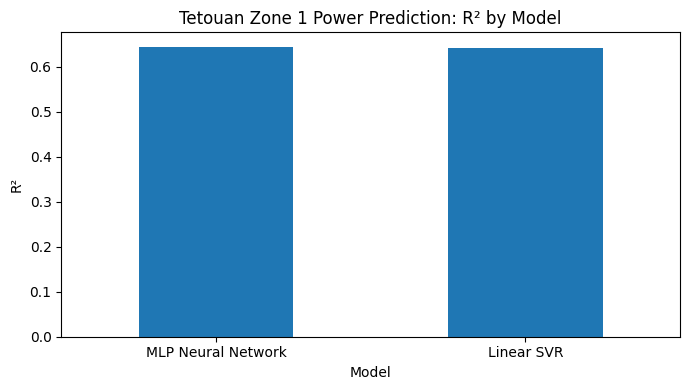

In [9]:
# Graph 1: R² comparison.
ax = results_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    legend=False,
    figsize=(7, 4),
    rot=0
)
ax.set_title("Tetouan Zone 1 Power Prediction: R² by Model")
ax.set_xlabel("Model")
ax.set_ylabel("R²")
plt.tight_layout()
plt.savefig(R2_GRAPH_PATH, dpi=200, bbox_inches="tight")
plt.show()

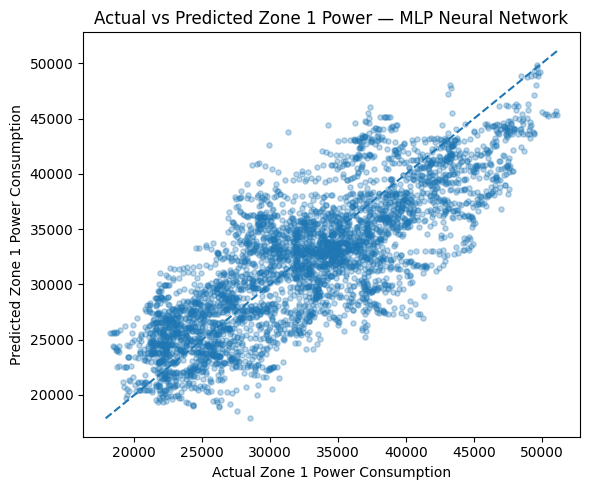

In [10]:
# Graph 2: Actual versus predicted values for the lower-RMSE model.
best_model_name = results_df.loc[0, "Model"]
best_predictions = prediction_table[best_model_name].to_numpy()

plt.figure(figsize=(6, 5))
plt.scatter(y_test, best_predictions, alpha=0.30, s=14)

lower = min(float(y_test.min()), float(best_predictions.min()))
upper = max(float(y_test.max()), float(best_predictions.max()))
plt.plot([lower, upper], [lower, upper], linestyle="--")

plt.title(f"Actual vs Predicted Zone 1 Power — {best_model_name}")
plt.xlabel("Actual Zone 1 Power Consumption")
plt.ylabel("Predicted Zone 1 Power Consumption")
plt.tight_layout()
plt.savefig(PRED_GRAPH_PATH, dpi=200, bbox_inches="tight")
plt.show()

Top predictors for MLP Neural Network:


,Feature,Importance
0,hour_sin,4174.3520
1,general diffuse flows,1525.8770
2,hour_cos,1321.8437
3,Temperature,1274.6857
4,diffuse flows,230.7806
5,Humidity,18.4238
6,dow_sin,-5.7555
7,month_cos,-54.8155
8,month_sin,-78.7024
9,Wind Speed,-271.7567


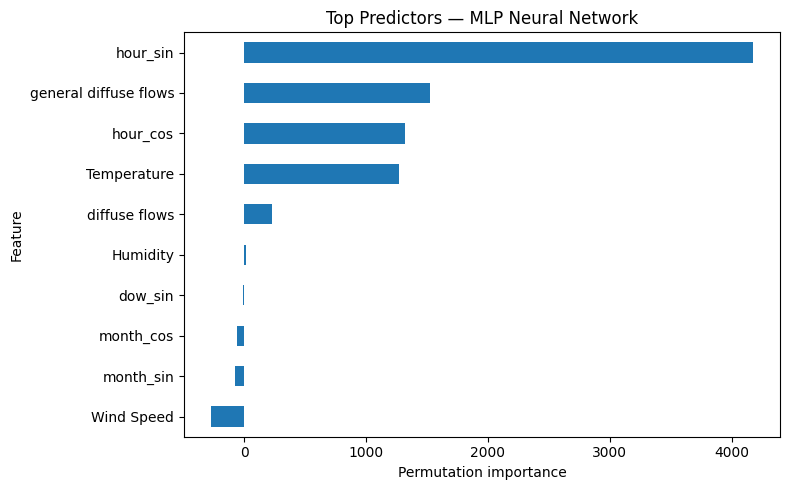

In [11]:
# Model-agnostic feature insight using permutation importance.
best_model = fitted_models[best_model_name]

sample_n = min(2000, len(X_test))
X_imp = X_test.iloc[:sample_n]
y_imp = y_test.iloc[:sample_n]

perm = permutation_importance(
    best_model,
    X_imp,
    y_imp,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": perm.importances_mean
    })
    .sort_values("Importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(f"Top predictors for {best_model_name}:")
display(importance_df.round(4))

ax = importance_df.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)
ax.set_title(f"Top Predictors — {best_model_name}")
ax.set_xlabel("Permutation importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(IMPORTANCE_GRAPH_PATH, dpi=200, bbox_inches="tight")
plt.show()

In [12]:
# Save all outputs to Google Drive.
results_df.to_csv(RESULT_PATH, index=False)
prediction_table.to_csv(PREDICTION_PATH, index=False)
importance_df.to_csv(IMPORTANCE_PATH, index=False)

print("Saved:")
print("-", RESULT_PATH)
print("-", PREDICTION_PATH)
print("-", IMPORTANCE_PATH)
print("-", R2_GRAPH_PATH)
print("-", PRED_GRAPH_PATH)
print("-", IMPORTANCE_GRAPH_PATH)

Saved:
- /content/drive/MyDrive/tetouan_power_model_results.csv
- /content/drive/MyDrive/tetouan_power_predictions.csv
- /content/drive/MyDrive/tetouan_power_feature_importance.csv
- /content/drive/MyDrive/tetouan_power_r2_comparison.png
- /content/drive/MyDrive/tetouan_power_actual_vs_predicted.png
- /content/drive/MyDrive/tetouan_power_feature_importance.png
